# Eco Predict — PM2.5 Forecasting ML Pipeline
**Location:** Gomti Nagar, Lucknow, Uttar Pradesh  
**Data:** CPCB/UPPCB hourly air-quality data (2024–2026)

### Goal
Build a **24-hour-ahead PM2.5 forecasting model** using historical pollution, weather, lag and calendar features.

The notebook:
1. Loads and combines the three yearly CSV files
2. Cleans and checks the time series
3. Performs EDA
4. Creates lag/rolling/calendar features
5. Uses a time-based train/test split
6. Trains baseline + Random Forest + HistGradientBoosting models
7. Evaluates MAE, RMSE and R²
8. Saves the best model and feature list
9. Generates example 24-hour forecasts


In [1]:
# 1. Imports
import os
import glob
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
FORECAST_HORIZON = 24  # hours ahead

# Project folders
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
RAW_DIR = os.path.join(BASE_DIR, "data", "raw")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")
MODEL_DIR = os.path.join(BASE_DIR, "models")

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print("Raw data folder:", RAW_DIR)
print("Files found:")
for f in glob.glob(os.path.join(RAW_DIR, "*.csv")):
    print(" -", os.path.basename(f))


Raw data folder: C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\data\raw
Files found:
 - air_2024.csv
 - air_2025.csv
 - air_2026.csv


In [2]:
# 2. Load all Gomti Nagar hourly CSV files
files = glob.glob(os.path.join(RAW_DIR, "*.csv"))

if not files:
    raise FileNotFoundError(
        "No CSV files found. Put the 2024, 2025 and 2026 Gomti Nagar CSV files in EcoPredict/data/raw/"
    )

frames = []
for file in files:
    temp = pd.read_csv(file)
    temp["source_file"] = os.path.basename(file)
    frames.append(temp)

df = pd.concat(frames, ignore_index=True)

print("Combined shape:", df.shape)
print(df.head())
print("\nColumns:")
print(df.columns.tolist())


Combined shape: (22632, 26)
             Timestamp  PM2.5 (µg/m³)  PM10 (µg/m³)  NO (µg/m³)  NO2 (µg/m³)  \
0  2024-01-01 00:00:00          36.00         86.50        1.82         5.18   
1  2024-01-01 01:00:00          37.00         89.00        1.80         5.10   
2  2024-01-01 02:00:00          32.25         80.00        1.80         5.10   
3  2024-01-01 03:00:00          30.25         75.25        1.80         5.10   
4  2024-01-01 04:00:00          29.00         73.00        1.80         5.10   

   NOx (ppb)  NH3 (µg/m³)  SO2 (µg/m³)  CO (mg/m³)  Ozone (µg/m³)  ...  \
0       6.50          NaN         6.02         NaN          46.25  ...   
1       6.43          NaN         5.17         NaN          45.80  ...   
2       6.43          NaN         8.32         NaN          45.58  ...   
3       6.40          NaN         9.00         NaN          45.48  ...   
4       6.43          NaN         9.75         NaN          45.50  ...   

   AT (°C)  RH (%)  WS (m/s)  WD (deg)  RF (mm

In [3]:
# 3. Basic cleaning
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

# Convert numeric columns
for col in df.columns:
    if col not in ["Timestamp", "source_file"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove invalid timestamps and duplicate timestamps
df = df.dropna(subset=["Timestamp"])
df = df.drop_duplicates(subset=["Timestamp"]).sort_values("Timestamp").reset_index(drop=True)

print("Date range:", df["Timestamp"].min(), "to", df["Timestamp"].max())
print("Rows after cleaning:", len(df))

# Check time gaps
time_diff = df["Timestamp"].diff().dt.total_seconds().div(3600)
print("\nTime-gap summary:")
print(time_diff.describe())

print("\nGaps greater than 1 hour:", (time_diff > 1).sum())


Date range: 2024-01-01 00:00:00 to 2026-08-31 23:00:00
Rows after cleaning: 22632

Time-gap summary:
count    22631.000000
mean         1.032875
std          4.945624
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        745.000000
Name: Timestamp, dtype: float64

Gaps greater than 1 hour: 1


In [4]:
# 4. Missing-value analysis
missing = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .to_frame("missing_percent")
)

display(missing)

# Main target
TARGET = "PM2.5 (µg/m³)"

if TARGET not in df.columns:
    raise ValueError(f"{TARGET} not found in dataset.")

print("Target:", TARGET)
print("Target missing:", df[TARGET].isna().sum())


,missing_percent
NH3 (µg/m³),100.000000
O Xylene (µg/m³),100.000000
Eth-Benzene (µg/m³),100.000000
MP-Xylene (µg/m³),100.000000
Xylene (µg/m³),80.620361
BP (mmHg),66.207140
SO2 (µg/m³),8.333333
Toluene (µg/m³),7.935666
Benzene (µg/m³),7.931248
CO (mg/m³),6.322906


Target: PM2.5 (µg/m³)
Target missing: 568


## 5. EDA — understand the data before ML

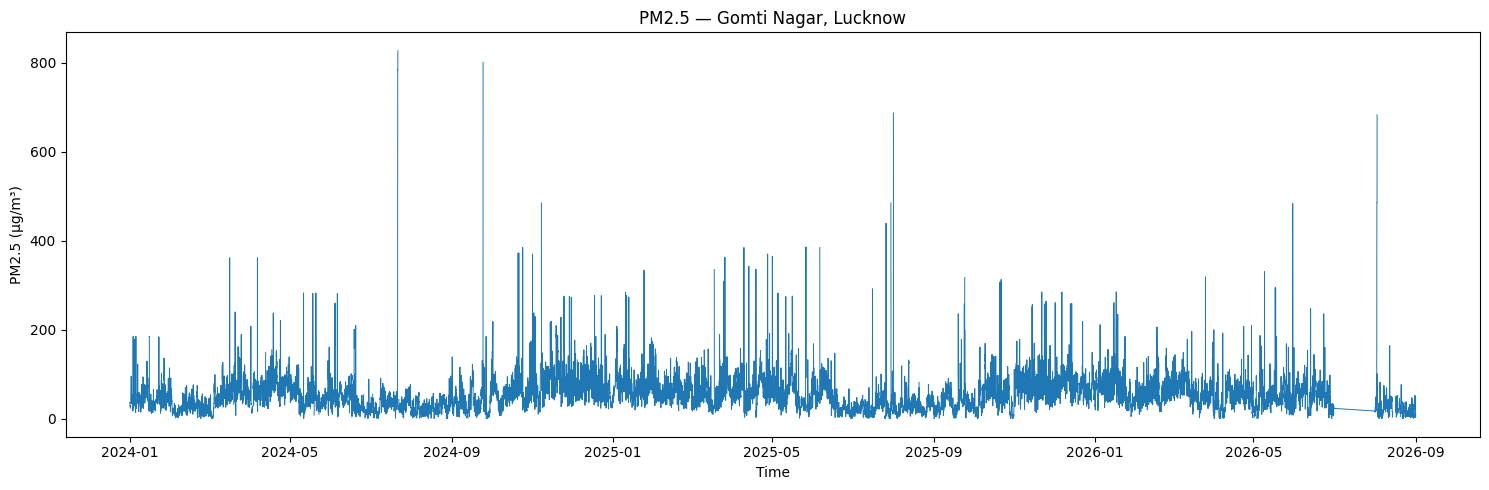

In [5]:
# 5.1 PM2.5 over time
plt.figure(figsize=(15, 5))
plt.plot(df["Timestamp"], df[TARGET], linewidth=0.7)
plt.title("PM2.5 — Gomti Nagar, Lucknow")
plt.xlabel("Time")
plt.ylabel("PM2.5 (µg/m³)")
plt.tight_layout()
plt.show()


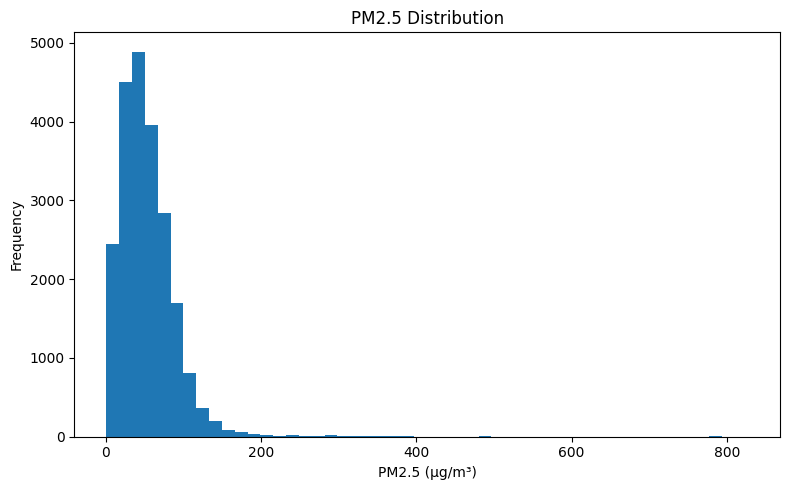

count    22064.000000
mean        53.991957
std         39.690118
min          1.000000
25%         29.250000
50%         47.750000
75%         70.750000
max        827.000000
Name: PM2.5 (µg/m³), dtype: float64


In [6]:
# 5.2 PM2.5 distribution
plt.figure(figsize=(8, 5))
plt.hist(df[TARGET].dropna(), bins=50)
plt.title("PM2.5 Distribution")
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print(df[TARGET].describe())


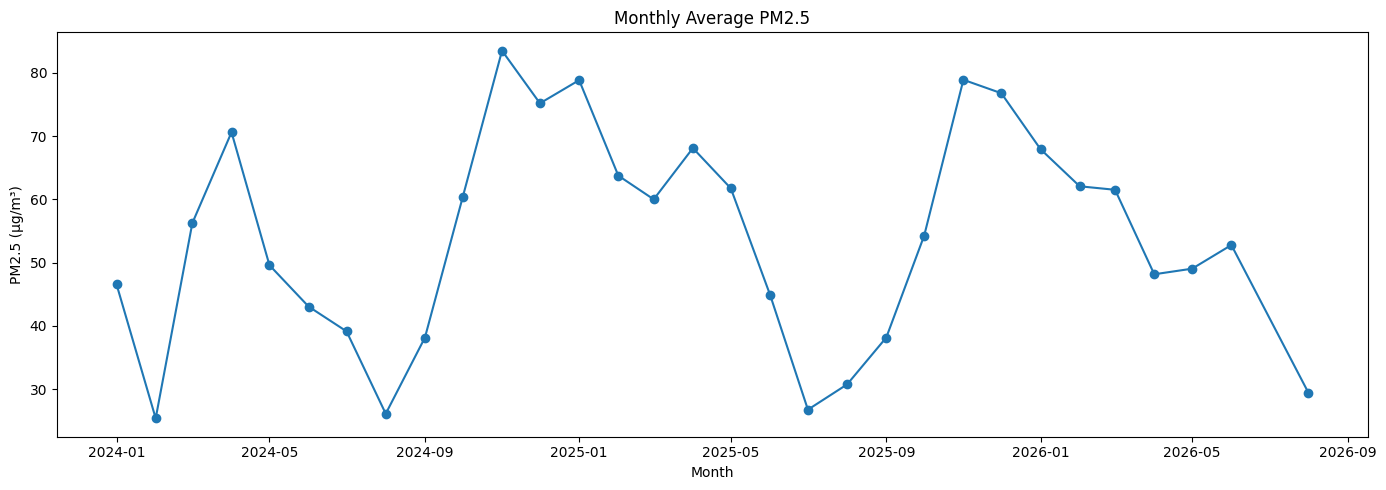

In [7]:
# 5.3 Monthly average PM2.5
monthly = (
    df.set_index("Timestamp")[TARGET]
      .resample("MS")
      .mean()
      .dropna()
)

plt.figure(figsize=(14, 5))
plt.plot(monthly.index, monthly.values, marker="o")
plt.title("Monthly Average PM2.5")
plt.xlabel("Month")
plt.ylabel("PM2.5 (µg/m³)")
plt.tight_layout()
plt.show()


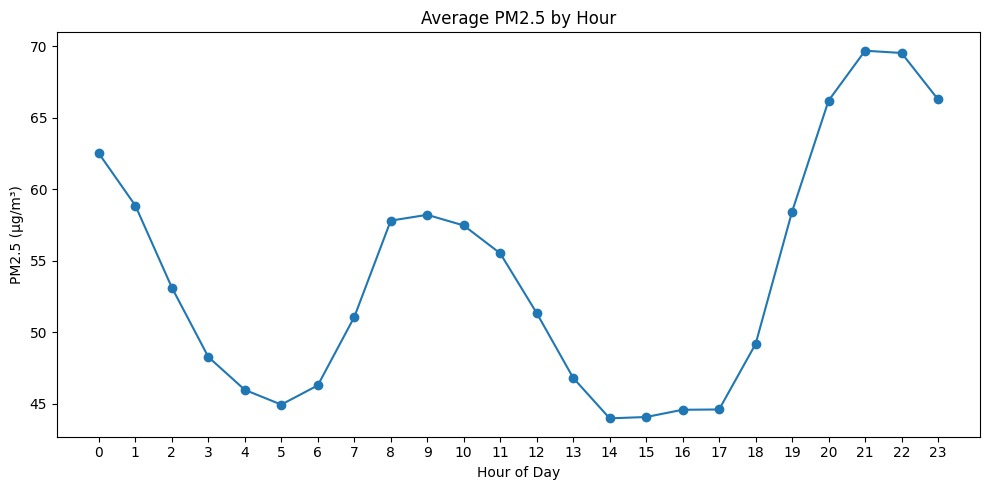

In [8]:
# 5.4 Hour-of-day pattern
hourly_avg = df.groupby(df["Timestamp"].dt.hour)[TARGET].mean()

plt.figure(figsize=(10, 5))
plt.plot(hourly_avg.index, hourly_avg.values, marker="o")
plt.title("Average PM2.5 by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("PM2.5 (µg/m³)")
plt.xticks(range(24))
plt.tight_layout()
plt.show()


In [9]:
# 5.5 Correlation with major numeric variables
major_cols = [
    "PM2.5 (µg/m³)", "PM10 (µg/m³)", "NO (µg/m³)", "NO2 (µg/m³)",
    "NOx (ppb)", "NH3 (µg/m³)", "SO2 (µg/m³)", "CO (mg/m³)",
    "Ozone (µg/m³)", "AT (°C)", "RH (%)", "WS (m/s)", "WD (deg)",
    "RF (mm)", "SR (W/mt2)", "BP (mmHg)", "VWS (m/s)"
]
major_cols = [c for c in major_cols if c in df.columns]

corr = df[major_cols].corr(numeric_only=True)[TARGET].sort_values(ascending=False)
print(corr)


PM2.5 (µg/m³)    1.000000
PM10 (µg/m³)     0.948915
WD (deg)         0.069081
SO2 (µg/m³)      0.035693
VWS (m/s)       -0.001616
RF (mm)         -0.025354
SR (W/mt2)      -0.033928
CO (mg/m³)      -0.060332
BP (mmHg)       -0.082483
NOx (ppb)       -0.083606
NO2 (µg/m³)     -0.083980
NO (µg/m³)      -0.087175
WS (m/s)        -0.113725
AT (°C)         -0.132481
RH (%)          -0.171449
Ozone (µg/m³)   -0.174453
NH3 (µg/m³)           NaN
Name: PM2.5 (µg/m³), dtype: float64


## 6. Feature engineering

We predict **PM2.5 24 hours in the future**.

Important: we only use information that would already be available at prediction time.  
Therefore, pollutant/weather values are used as **lagged features**, not future values.


In [10]:
# SIMPLE FEATURE ENGINEERING

data = df.copy()

# Time features
data["hour"] = data["Timestamp"].dt.hour
data["day_of_week"] = data["Timestamp"].dt.dayofweek
data["month"] = data["Timestamp"].dt.month

# PM2.5 lag features
for lag in [1, 3, 6, 12, 24, 48, 72]:
    data[f"pm25_lag_{lag}"] = data[TARGET].shift(lag)

# Rolling averages
data["pm25_roll_6"] = data[TARGET].shift(1).rolling(6).mean()
data["pm25_roll_24"] = data[TARGET].shift(1).rolling(24).mean()

# Target = PM2.5 after 24 hours
data["target_pm25_24h"] = data[TARGET].shift(-24)

FEATURES = [
    "hour",
    "day_of_week",
    "month",
    "pm25_lag_1",
    "pm25_lag_3",
    "pm25_lag_6",
    "pm25_lag_12",
    "pm25_lag_24",
    "pm25_lag_48",
    "pm25_lag_72",
    "pm25_roll_6",
    "pm25_roll_24"
]

model_data = data[
    ["Timestamp", TARGET, "target_pm25_24h"] + FEATURES
].dropna().reset_index(drop=True)

print("ML dataset:", model_data.shape)

ML dataset: (18151, 15)


In [11]:
# # 6.2 Select features
# calendar_features = [
#     "hour", "day_of_week", "day_of_month", "month",
#     "day_of_year", "is_weekend",
#     "hour_sin", "hour_cos", "month_sin", "month_cos"
# ]

# lag_features = [
#     c for c in data.columns
#     if "_lag_" in c or c.startswith("pm25_roll_")
# ]

# FEATURES = calendar_features + lag_features

# # Keep only columns that exist
# FEATURES = [c for c in FEATURES if c in data.columns]

# model_data = data[["Timestamp", "target_pm25_24h"] + FEATURES].copy()

# # Remove rows without target/features
# model_data = model_data.replace([np.inf, -np.inf], np.nan)
# model_data = model_data.dropna().reset_index(drop=True)

# print("Final ML dataset:", model_data.shape)
# print("Number of features:", len(FEATURES))


In [12]:
# Train = 2024-2025
# Test = 2026

train = model_data[model_data["Timestamp"].dt.year < 2026]
test = model_data[model_data["Timestamp"].dt.year == 2026]

X_train = train[FEATURES]
y_train = train["target_pm25_24h"]

X_test = test[FEATURES]
y_test = test["target_pm25_24h"]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (13826, 12)
X_test : (4325, 12)


## 8. Baseline model

First compare ML against a simple persistence baseline:

> Tomorrow's PM2.5 ≈ current PM2.5

Because the target is 24 hours ahead, this is represented by the current PM2.5 value at time *t*.


In [13]:
# Baseline: current PM2.5 predicts PM2.5 24 hours ahead

# Get current PM2.5 using Timestamp
current_pm25 = df.set_index("Timestamp")[TARGET]

# Match current PM2.5 to test timestamps
baseline_pred = test["Timestamp"].map(current_pm25)

# Actual 24-hour-ahead PM2.5
y_baseline = test["target_pm25_24h"]

# Keep only valid rows
mask = y_baseline.notna() & baseline_pred.notna()

y_baseline = y_baseline[mask]
baseline_pred = baseline_pred[mask]

print("Valid baseline samples:", len(y_baseline))

baseline_mae = mean_absolute_error(y_baseline, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_baseline, baseline_pred))
baseline_r2 = r2_score(y_baseline, baseline_pred)

print(f"Baseline MAE  : {baseline_mae:.3f}")
print(f"Baseline RMSE : {baseline_rmse:.3f}")
print(f"Baseline R²   : {baseline_r2:.3f}")

Valid baseline samples: 4325
Baseline MAE  : 24.195
Baseline RMSE : 46.164
Baseline R²   : -0.502


## 9. Train ML models

In [14]:
# 9.1 Random Forest
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest MAE : {rf_mae:.3f}")
print(f"Random Forest RMSE: {rf_rmse:.3f}")
print(f"Random Forest R²  : {rf_r2:.3f}")


Random Forest MAE : 21.075
Random Forest RMSE: 35.479
Random Forest R²  : 0.113


In [15]:
# 9.2 HistGradientBoosting
hgb = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=RANDOM_STATE
)

hgb.fit(X_train, y_train)
hgb_pred = hgb.predict(X_test)

hgb_mae = mean_absolute_error(y_test, hgb_pred)
hgb_rmse = np.sqrt(mean_squared_error(y_test, hgb_pred))
hgb_r2 = r2_score(y_test, hgb_pred)

print(f"HistGradientBoosting MAE : {hgb_mae:.3f}")
print(f"HistGradientBoosting RMSE: {hgb_rmse:.3f}")
print(f"HistGradientBoosting R²  : {hgb_r2:.3f}")


HistGradientBoosting MAE : 20.946
HistGradientBoosting RMSE: 35.315
HistGradientBoosting R²  : 0.121


In [16]:
# 10. Compare models
results = pd.DataFrame({
    "Model": ["Persistence Baseline", "Random Forest", "HistGradientBoosting"],
    "MAE": [baseline_mae, rf_mae, hgb_mae],
    "RMSE": [baseline_rmse, rf_rmse, hgb_rmse],
    "R2": [baseline_r2, rf_r2, hgb_r2]
}).sort_values("MAE")

display(results)

best_name = results.iloc[0]["Model"]
print("Best by MAE:", best_name)


,Model,MAE,RMSE,R2
2,HistGradientBoosting,20.946440,35.315112,0.121200
1,Random Forest,21.075228,35.478733,0.113038
0,Persistence Baseline,24.194671,46.163516,-0.501642


Best by MAE: HistGradientBoosting


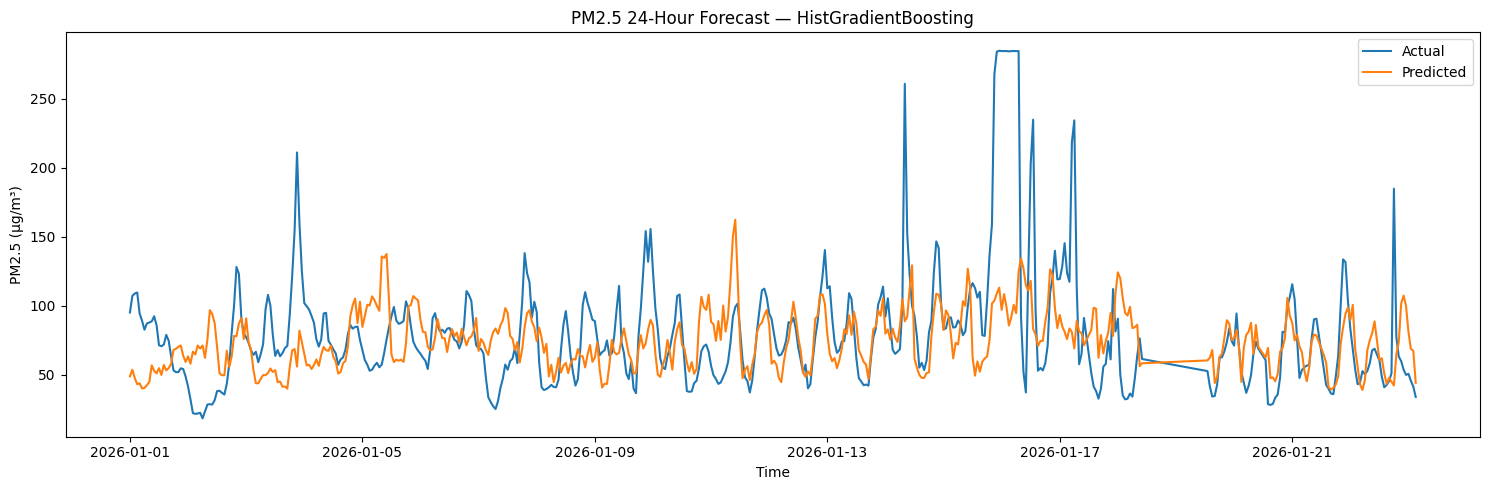

In [17]:
# 11. Actual vs predicted for the best ML model
if hgb_mae <= rf_mae:
    best_model = hgb
    best_pred = hgb_pred
    best_model_name = "HistGradientBoosting"
else:
    best_model = rf
    best_pred = rf_pred
    best_model_name = "Random Forest"

plt.figure(figsize=(15, 5))
plt.plot(test["Timestamp"].iloc[:500], y_test.iloc[:500].values, label="Actual")
plt.plot(test["Timestamp"].iloc[:500], best_pred[:500], label="Predicted")
plt.title(f"PM2.5 24-Hour Forecast — {best_model_name}")
plt.xlabel("Time")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.tight_layout()
plt.show()


Mean Absolute Error: 20.946440236314228
RMSE: 35.31511203986772
R²: 0.12120030019184458


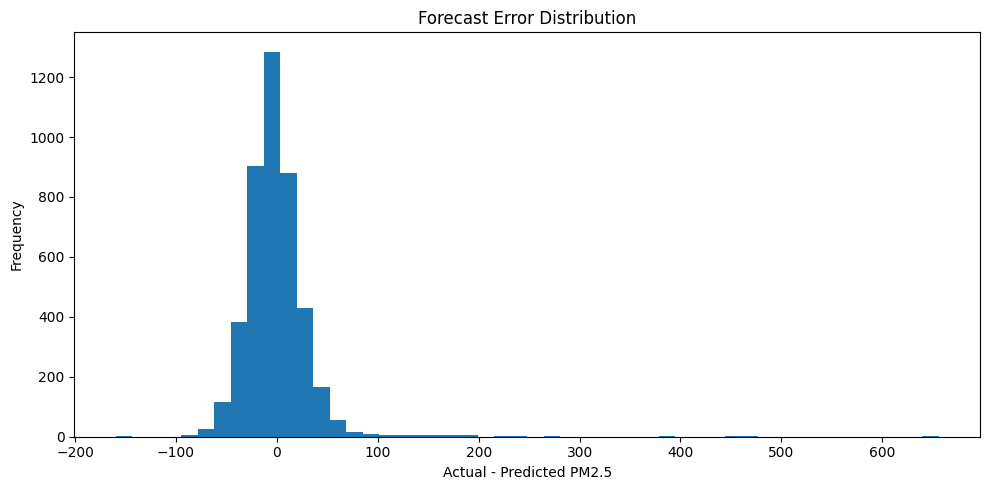

In [18]:
# 12. Error analysis
errors = y_test.values - best_pred

print("Mean Absolute Error:", mean_absolute_error(y_test, best_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, best_pred)))
print("R²:", r2_score(y_test, best_pred))

plt.figure(figsize=(10, 5))
plt.hist(errors, bins=50)
plt.title("Forecast Error Distribution")
plt.xlabel("Actual - Predicted PM2.5")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [19]:
# 13. Feature importance
if hasattr(best_model, "feature_importances_"):
    importance = pd.Series(
        best_model.feature_importances_,
        index=FEATURES
    ).sort_values(ascending=False).head(20)

    plt.figure(figsize=(10, 7))
    importance.sort_values().plot(kind="barh")
    plt.title("Top 20 Feature Importances")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    display(importance.to_frame("importance"))
else:
    print("Feature importance is not directly available for this model.")


Feature importance is not directly available for this model.


## 14. Save the trained model

The backend will later load these files to serve predictions.


In [20]:
# Save model package
model_package = {
    "model": best_model,
    "features": FEATURES,
    "target": TARGET,
    "forecast_horizon_hours": FORECAST_HORIZON,
    "location": "Gomti Nagar, Lucknow, Uttar Pradesh",
    "model_name": best_model_name
}

model_path = os.path.join(MODEL_DIR, "pm25_forecaster_24h.joblib")
joblib.dump(model_package, model_path)

# Save metrics
metrics_path = os.path.join(MODEL_DIR, "pm25_model_metrics.csv")
results.to_csv(metrics_path, index=False)

# Save cleaned ML dataset
processed_path = os.path.join(PROCESSED_DIR, "pm25_ml_dataset.csv")
model_data.to_csv(processed_path, index=False)

print("Saved:")
print(model_path)
print(metrics_path)
print(processed_path)


Saved:
C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\models\pm25_forecaster_24h.joblib
C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\models\pm25_model_metrics.csv
C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\data\processed\pm25_ml_dataset.csv


## 15. Generate the latest 24-hour forecast

This uses the latest available historical row and its lag features.


In [21]:
# Latest available feature row
latest_row = model_data.iloc[[-1]]
latest_timestamp = latest_row["Timestamp"].iloc[0]

latest_prediction = best_model.predict(latest_row[FEATURES])[0]

print("Prediction time:", latest_timestamp)
print("Forecast horizon:", FORECAST_HORIZON, "hours")
print(f"Predicted PM2.5 after 24 hours: {latest_prediction:.2f} µg/m³")


Prediction time: 2026-08-30 23:00:00
Forecast horizon: 24 hours
Predicted PM2.5 after 24 hours: 49.43 µg/m³


In [22]:
# 16. Create a simple risk category for the prototype
# This is a screening indicator, not an official regulatory classification.
def pollution_risk(pm25):
    if pm25 <= 30:
        return "Low"
    elif pm25 <= 60:
        return "Moderate"
    elif pm25 <= 90:
        return "High"
    else:
        return "Critical"

print("Forecast risk:", pollution_risk(latest_prediction))


Forecast risk: Moderate


# Day 1 ML output

After running all cells, you should have:

- Cleaned 2024–2026 hourly dataset
- PM2.5 EDA
- 24-hour forecasting features
- Baseline model
- Random Forest model
- HistGradientBoosting model
- MAE / RMSE / R² comparison
- Actual vs predicted graph
- Feature importance
- Saved model: `models/pm25_forecaster_24h.joblib`
- Saved metrics: `models/pm25_model_metrics.csv`

### Important
Do **not** tune endlessly today. The goal is a working, explainable prototype model that we can connect to the Eco Predict backend.
